# Boulder Orientation Annotation Tool (run locally)

Loads exported boulder crops from `boulder_crops_export.ipynb`, lets you annotate orientations by clicking, then compares your annotations against each model.

**Workflow:**
1. Run `boulder_crops_export.ipynb` on Sherlock → downloads a `boulder_annotation_crops/` directory
2. Point `CROPS_DIR` below at that directory
3. Run the annotation session — click two points along each boulder's long axis
4. Run the comparison section

**Controls during annotation:**
- Click twice to draw an orientation line
- `u` — undo last click
- `n` — skip this boulder
- `q` — quit and save
- Closing the window also saves

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("TkAgg")   # interactive backend; try "Qt5Agg" if TkAgg unavailable
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from pathlib import Path
from datetime import datetime
from scipy.stats import kstest

print("Imports OK")

Imports OK


In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
# Point this at the directory you scp'd from Sherlock
CROPS_DIR = Path("/Users/cayleigh/Desktop/boulder_annotation_crops")

ANNOTATIONS_CSV = CROPS_DIR / "user_annotations.csv"

# Model display config
MODEL_COLS = ["yolo", "sam2_zs", "sam2_ft", "sam2_auto"]
MODEL_LABELS = {
    "yolo":     "YOLOv8",
    "sam2_zs":  "SAM2 zero-shot",
    "sam2_ft":  "SAM2 fine-tuned",
    "sam2_auto":"SAM2-auto",
}
MODEL_COLORS = {
    "yolo":     "steelblue",
    "sam2_zs":  "tomato",
    "sam2_ft":  "darkorange",
    "sam2_auto":"mediumpurple",
}

assert CROPS_DIR.exists(), f"CROPS_DIR not found: {CROPS_DIR}"
df_meta = pd.read_csv(CROPS_DIR / "metadata.csv", dtype={"boulder_id": str})
print(f"Loaded {len(df_meta)} boulders")
print("Columns:", df_meta.columns.tolist())

# Identify which model angle columns are present
angle_cols = {m: f"{m}_angle" for m in MODEL_COLS if f"{m}_angle" in df_meta.columns}
print("Model angle columns found:", list(angle_cols.values()))

Loaded 100 boulders
Columns: ['boulder_id', 'area_m2', 'sam2_ft_angle', 'sam2_ft_ar', 'sam2_zs_angle', 'sam2_zs_ar', 'yolo_angle', 'yolo_ar', 'sam2_auto_angle', 'sam2_auto_ar']
Model angle columns found: ['yolo_angle', 'sam2_zs_angle', 'sam2_ft_angle', 'sam2_auto_angle']


In [3]:
# ── Annotation utilities ──────────────────────────────────────────────────────

def angle_from_clicks(p1, p2):
    dx =  (p2[0] - p1[0])
    dy = -(p2[1] - p1[1])
    math_angle = np.degrees(np.arctan2(dy, dx)) % 180
    geo_angle  = (90 - math_angle) % 180
    return float(geo_angle)


def draw_angle_line(ax, angle180, cx, cy, size, color, lw=2, label=None):
    L   = size * 0.38
    rad = np.radians(angle180)
    dx  =  np.sin(rad) * L
    dy  = -np.cos(rad) * L
    ax.plot([cx - dx, cx + dx], [cy - dy, cy + dy],
            color=color, lw=lw, label=label, solid_capstyle="round")


def load_annotations():
    if ANNOTATIONS_CSV.exists():
        return pd.read_csv(ANNOTATIONS_CSV, dtype={"boulder_id": str})
    return pd.DataFrame(columns=["boulder_id", "user_angle", "annotated_at"])


print("Utilities defined")

Utilities defined


In [4]:
# ── Annotation session ────────────────────────────────────────────────────────

df_annot   = load_annotations()
done_ids   = set(df_annot["boulder_id"].astype(str).tolist())
new_annots = []

todo = df_meta[~df_meta["boulder_id"].astype(str).isin(done_ids)].reset_index(drop=True)
print(f"{len(done_ids)} already annotated, {len(todo)} remaining")

for _, row in todo.iterrows():
    bid      = str(row["boulder_id"])
    crop_img = cv2.imread(str(CROPS_DIR / "crops" / f"{bid}.png"), cv2.IMREAD_GRAYSCALE)
    ovl_img  = cv2.imread(str(CROPS_DIR / "overlays" / f"{bid}.png"), cv2.IMREAD_COLOR)
    if crop_img is None:
        continue
    ovl_rgb  = cv2.cvtColor(ovl_img, cv2.COLOR_BGR2RGB) if ovl_img is not None else None

    H, W  = crop_img.shape
    cx, cy = W // 2, H // 2

    # Build figure: left = clean crop for clicking, right = overlay for reference
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(crop_img, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title("← Click here: draw your orientation line", fontsize=9)
    axes[0].axis("off")

    if ovl_rgb is not None:
        axes[1].imshow(ovl_rgb)
    else:
        axes[1].imshow(crop_img, cmap="gray")

    # Draw model lines on right panel
    legend_handles = []
    for mkey, acol in angle_cols.items():
        a = row.get(acol)
        if pd.notna(a):
            draw_angle_line(axes[1], a, cx, cy, min(H, W),
                            MODEL_COLORS[mkey], lw=2,
                            label=f"{MODEL_LABELS[mkey]}: {a:.0f}°")
            legend_handles.append(
                mpatches.Patch(color=MODEL_COLORS[mkey], label=f"{MODEL_LABELS[mkey]}: {a:.0f}°"))
    if legend_handles:
        axes[1].legend(handles=legend_handles, loc="upper right", fontsize=7, framealpha=0.8)
    axes[1].set_title("Model orientations (reference)", fontsize=9)
    axes[1].axis("off")

    fig.suptitle(f"Boulder #{bid}  |  area={row['area_m2']:.1f} m²  |  "
                 f"n=skip  u=undo  q=quit", fontsize=9)

    clicked  = []
    skipped  = [False]
    quit_now = [False]
    click_dots = []
    user_line  = [None]

    def on_click(event):
        if event.inaxes != axes[0] or event.xdata is None:
            return
        clicked.append((event.xdata, event.ydata))
        dot, = axes[0].plot(event.xdata, event.ydata, "y+", ms=14, mew=2.5)
        click_dots.append(dot)
        if len(clicked) == 2:
            if user_line[0]:
                user_line[0].remove()
            line, = axes[0].plot([clicked[0][0], clicked[1][0]],
                                  [clicked[0][1], clicked[1][1]],
                                  "y-", lw=2.5)
            user_line[0] = line
            angle = angle_from_clicks(clicked[0], clicked[1])
            axes[0].set_title(f"Your line: {angle:.1f}°  (press any key to confirm, u to redo)",
                              fontsize=9, color="gold")
        fig.canvas.draw_idle()

    def on_key(event):
        if event.key == "n":
            skipped[0] = True
            plt.close(fig)
        elif event.key == "q":
            quit_now[0] = True
            plt.close(fig)
        elif event.key == "u":
            if clicked:
                clicked.pop()
            if click_dots:
                click_dots.pop().remove()
            if user_line[0] and len(clicked) < 2:
                user_line[0].remove()
                user_line[0] = None
            axes[0].set_title("← Click here: draw your orientation line", fontsize=9)
            fig.canvas.draw_idle()
        elif len(clicked) == 2:   # any other key = confirm
            plt.close(fig)

    fig.canvas.mpl_connect("button_press_event", on_click)
    fig.canvas.mpl_connect("key_press_event", on_key)
    plt.tight_layout()
    plt.show(block=True)

    if quit_now[0]:
        print("Session ended")
        break
    if skipped[0] or len(clicked) < 2:
        continue

    user_angle = angle_from_clicks(clicked[0], clicked[1])
    new_annots.append({"boulder_id": bid, "user_angle": user_angle,
                       "annotated_at": datetime.now().isoformat()})
    print(f"  #{bid}: {user_angle:.1f}°  "
          + "  ".join(f"{MODEL_LABELS[m]}={row.get(c, float('nan')):.0f}°"
                      for m, c in angle_cols.items() if pd.notna(row.get(c))))

if new_annots:
    df_new   = pd.DataFrame(new_annots)
    df_annot = pd.concat([df_annot, df_new], ignore_index=True)
    df_annot.to_csv(ANNOTATIONS_CSV, index=False)
    print(f"\nSaved {len(new_annots)} new annotations ({len(df_annot)} total) → {ANNOTATIONS_CSV}")

69 already annotated, 31 remaining
  #00017: 150.8°  YOLOv8=94°  SAM2 zero-shot=143°  SAM2 fine-tuned=114°
  #00026: 40.0°  YOLOv8=35°  SAM2 zero-shot=34°  SAM2 fine-tuned=27°
  #00034: 39.5°  YOLOv8=43°  SAM2 zero-shot=13°  SAM2 fine-tuned=169°
  #00037: 131.5°  YOLOv8=135°  SAM2 zero-shot=97°  SAM2 fine-tuned=104°
  #00041: 94.3°  YOLOv8=86°  SAM2 zero-shot=77°  SAM2 fine-tuned=98°
  #00045: 26.1°  YOLOv8=6°  SAM2 zero-shot=15°  SAM2 fine-tuned=5°
  #00046: 30.9°  YOLOv8=31°  SAM2 zero-shot=14°  SAM2 fine-tuned=25°  SAM2-auto=6°
  #00069: 1.5°  YOLOv8=169°  SAM2 zero-shot=15°  SAM2 fine-tuned=172°
  #00071: 71.2°  SAM2 zero-shot=74°  SAM2 fine-tuned=75°
  #00072: 128.7°  YOLOv8=123°  SAM2 zero-shot=131°  SAM2 fine-tuned=136°  SAM2-auto=123°
  #00084: 129.1°  YOLOv8=138°  SAM2 zero-shot=154°  SAM2 fine-tuned=155°  SAM2-auto=142°
  #00086: 145.0°  YOLOv8=153°  SAM2 zero-shot=155°  SAM2 fine-tuned=142°
  #00087: 111.8°  YOLOv8=122°  SAM2 zero-shot=128°  SAM2 fine-tuned=125°  SAM2-auto=9

In [5]:
# ── Merge annotations with model data ─────────────────────────────────────────
matplotlib.use("inline")   # switch back to inline for comparison plots
%matplotlib inline

df_annot = load_annotations()
print(f"{len(df_annot)} annotations loaded")
if len(df_annot) < 5:
    print("Annotate more boulders first")
else:
    df_merged = df_annot.merge(df_meta, on="boulder_id", how="left")
    print(f"Merged with metadata: {len(df_merged)} rows")
    print(df_merged[["boulder_id", "user_angle"] + list(angle_cols.values())].head(10).to_string(index=False))

93 annotations loaded
Merged with metadata: 93 rows
boulder_id  user_angle  yolo_angle  sam2_zs_angle  sam2_ft_angle  sam2_auto_angle
     00000   11.798792         NaN       7.790417      20.291810              NaN
     00001   32.969404    2.358719      22.005905       3.441953              NaN
     00002    1.548158   39.183493      11.370046      71.564556              NaN
     00003   88.901813   92.384592      86.765213     125.143820              NaN
     00004   30.300947   23.583137      23.684490      24.357610              NaN
     00005  142.431408  105.686682      65.788456      86.855893              NaN
     00006   93.070394   80.835810      81.956776      90.834606              NaN
     00007  137.469130   98.930658     111.114952     135.533397              NaN
     00008  138.056580  162.333789     172.725717     172.267742              NaN
     00009   55.434076   87.357712      71.355663      87.732345        83.232017


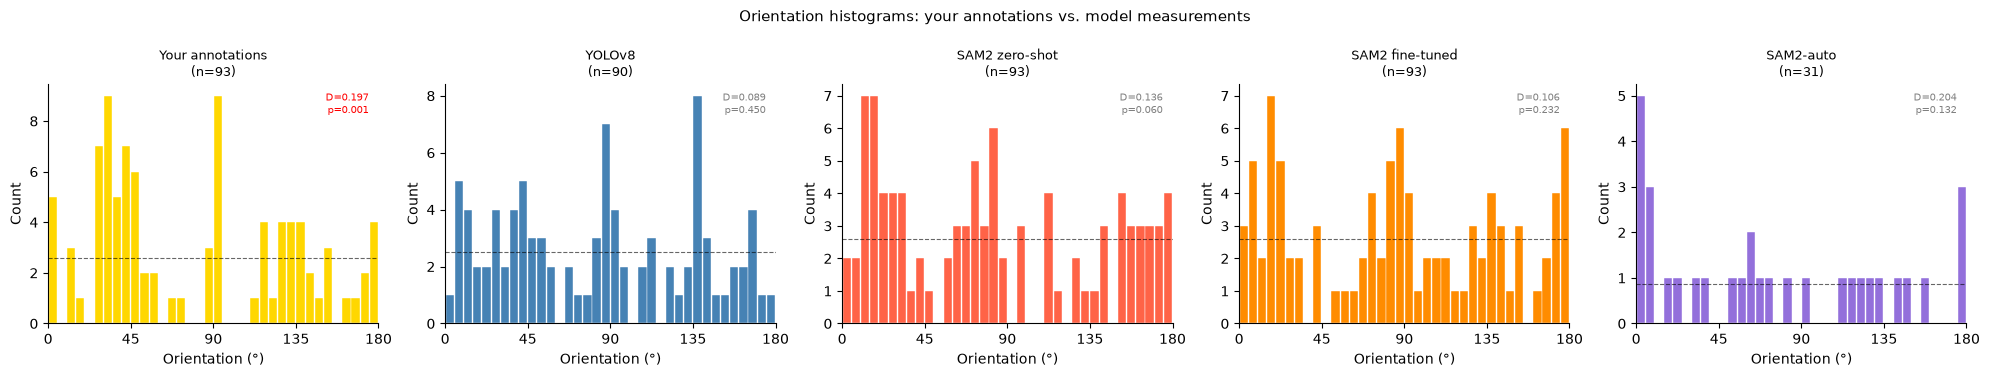

In [6]:
# ── Orientation histograms: you vs. each model ────────────────────────────────

BINS = np.linspace(0, 180, 37)
CX   = (BINS[:-1] + BINS[1:]) / 2

plot_cols = [("user_angle", "Your annotations", "gold")]
for mkey, acol in angle_cols.items():
    plot_cols.append((acol, MODEL_LABELS[mkey], MODEL_COLORS[mkey]))

fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 3.8))

for ax, (col, label, color) in zip(axes, plot_cols):
    angles = df_merged[col].dropna().values
    if len(angles) == 0:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(label)
        continue
    counts, _ = np.histogram(angles, bins=BINS)
    ax.bar(CX, counts, width=4.5, color=color, edgecolor="white", lw=0.3)
    ax.axhline(len(angles) / len(CX), color="k", ls="--", lw=0.8, alpha=0.6)
    ax.set(xlim=(0, 180), xticks=[0, 45, 90, 135, 180],
           xlabel="Orientation (°)", ylabel="Count")
    ax.set_title(f"{label}\n(n={len(angles)})", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    D, p = kstest(angles / 180.0, "uniform")
    ax.text(0.97, 0.97, f"D={D:.3f}\np={p:.3f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
            color="red" if p < 0.05 else "gray")

plt.suptitle("Orientation histograms: your annotations vs. model measurements", fontsize=11)
plt.tight_layout()
plt.savefig(CROPS_DIR / "comparison_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

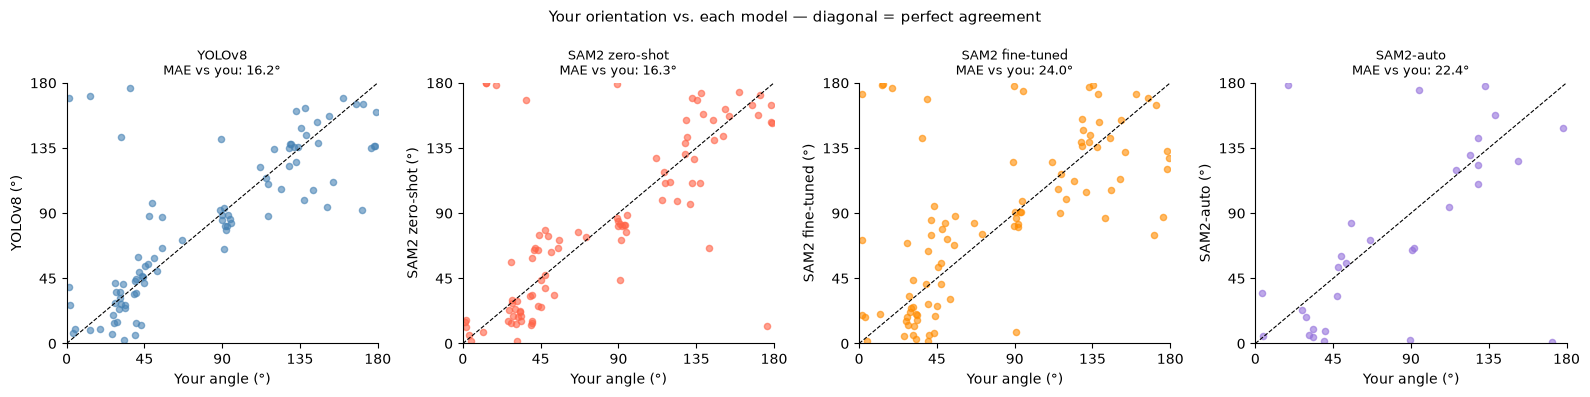

In [7]:
# ── Scatter: your angle vs. each model ────────────────────────────────────────

fig, axes = plt.subplots(1, len(angle_cols), figsize=(4 * len(angle_cols), 4))
if len(angle_cols) == 1:
    axes = [axes]

for ax, (mkey, acol) in zip(axes, angle_cols.items()):
    valid = df_merged[["user_angle", acol]].dropna()
    color = MODEL_COLORS[mkey]
    if valid.empty:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(MODEL_LABELS[mkey])
        continue
    ax.scatter(valid["user_angle"], valid[acol], s=20, alpha=0.6, color=color)
    ax.plot([0, 180], [0, 180], "k--", lw=0.8)
    errors = np.minimum(
        np.abs(valid["user_angle"].values - valid[acol].values),
        180 - np.abs(valid["user_angle"].values - valid[acol].values)
    )
    mae = np.mean(errors)
    ax.set(xlim=(0, 180), ylim=(0, 180),
           xticks=[0, 45, 90, 135, 180], yticks=[0, 45, 90, 135, 180],
           xlabel="Your angle (°)", ylabel=f"{MODEL_LABELS[mkey]} (°)")
    ax.set_title(f"{MODEL_LABELS[mkey]}\nMAE vs you: {mae:.1f}°", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Your orientation vs. each model — diagonal = perfect agreement", fontsize=11)
plt.tight_layout()
plt.savefig(CROPS_DIR / "comparison_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── Error summary table ───────────────────────────────────────────────────────

rows = []
for mkey, acol in angle_cols.items():
    valid = df_merged[["user_angle", acol]].dropna()
    if valid.empty:
        rows.append({"Model": MODEL_LABELS[mkey], "n": 0, "MAE (°)": "-",
                     "Median err (°)": "-", "% within 10°": "-", "% within 30°": "-"})
        continue
    errs = np.minimum(
        np.abs(valid["user_angle"].values - valid[acol].values),
        180 - np.abs(valid["user_angle"].values - valid[acol].values)
    )
    rows.append({
        "Model":         MODEL_LABELS[mkey],
        "n":             len(valid),
        "MAE (°)":       f"{np.mean(errs):.1f}",
        "Median err (°)":f"{np.median(errs):.1f}",
        "% within 10°":  f"{100 * np.mean(errs <= 10):.0f}%",
        "% within 30°":  f"{100 * np.mean(errs <= 30):.0f}%",
    })

df_summary = pd.DataFrame(rows)
print("Agreement with your annotations:")
print(df_summary.to_string(index=False))
df_summary.to_csv(CROPS_DIR / "comparison_summary.csv", index=False)

Agreement with your annotations:
          Model  n MAE (°) Median err (°) % within 10° % within 30°
         YOLOv8 90    16.2            8.7          54%          80%
 SAM2 zero-shot 93    16.3           13.3          35%          89%
SAM2 fine-tuned 93    24.0           16.6          31%          70%
      SAM2-auto 31    22.4           19.2          29%          81%


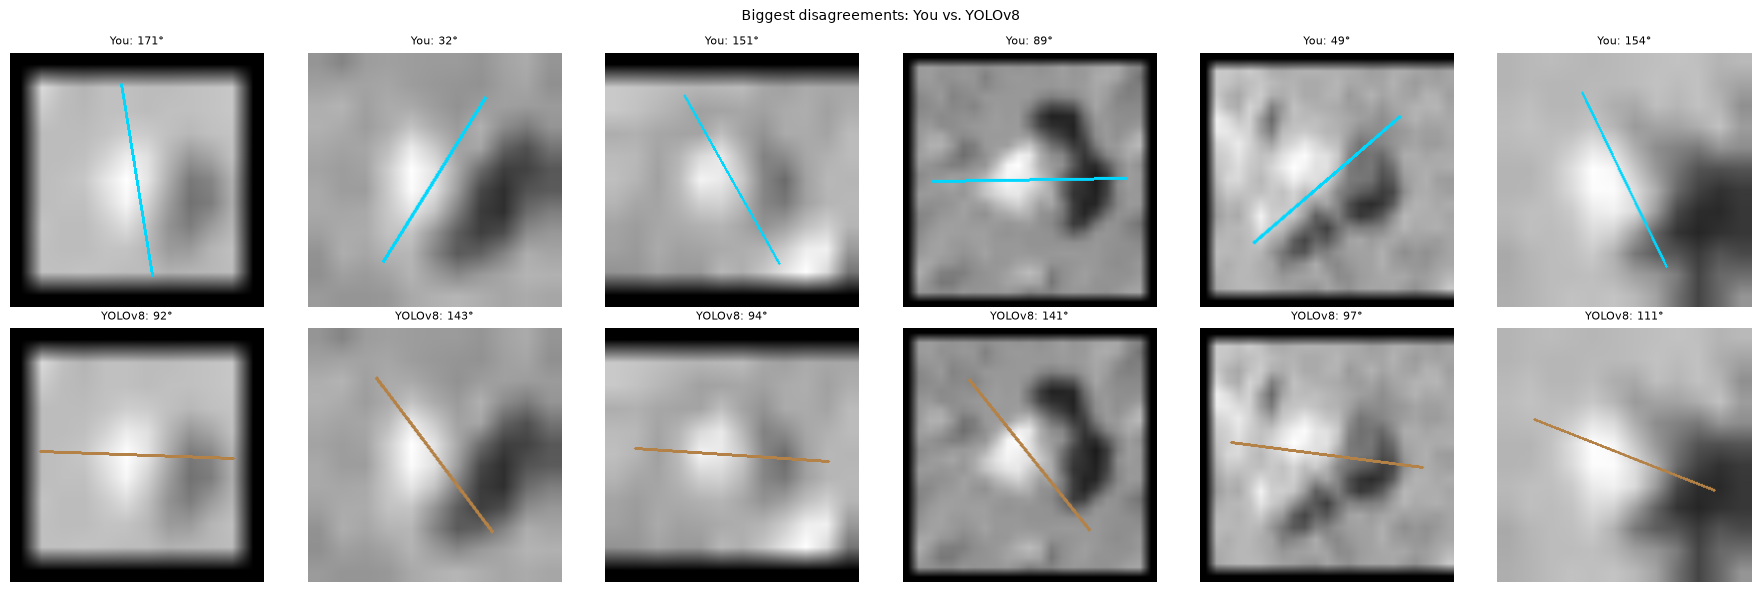

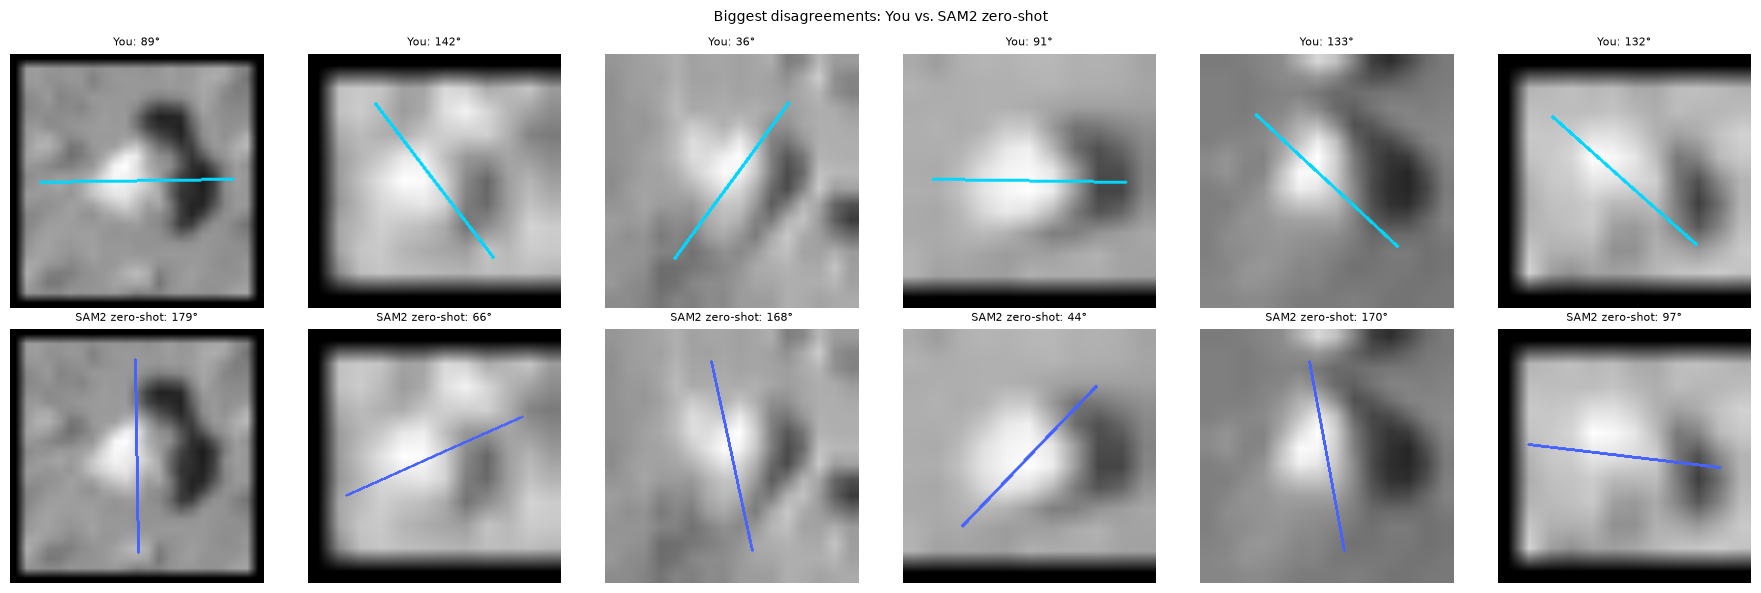

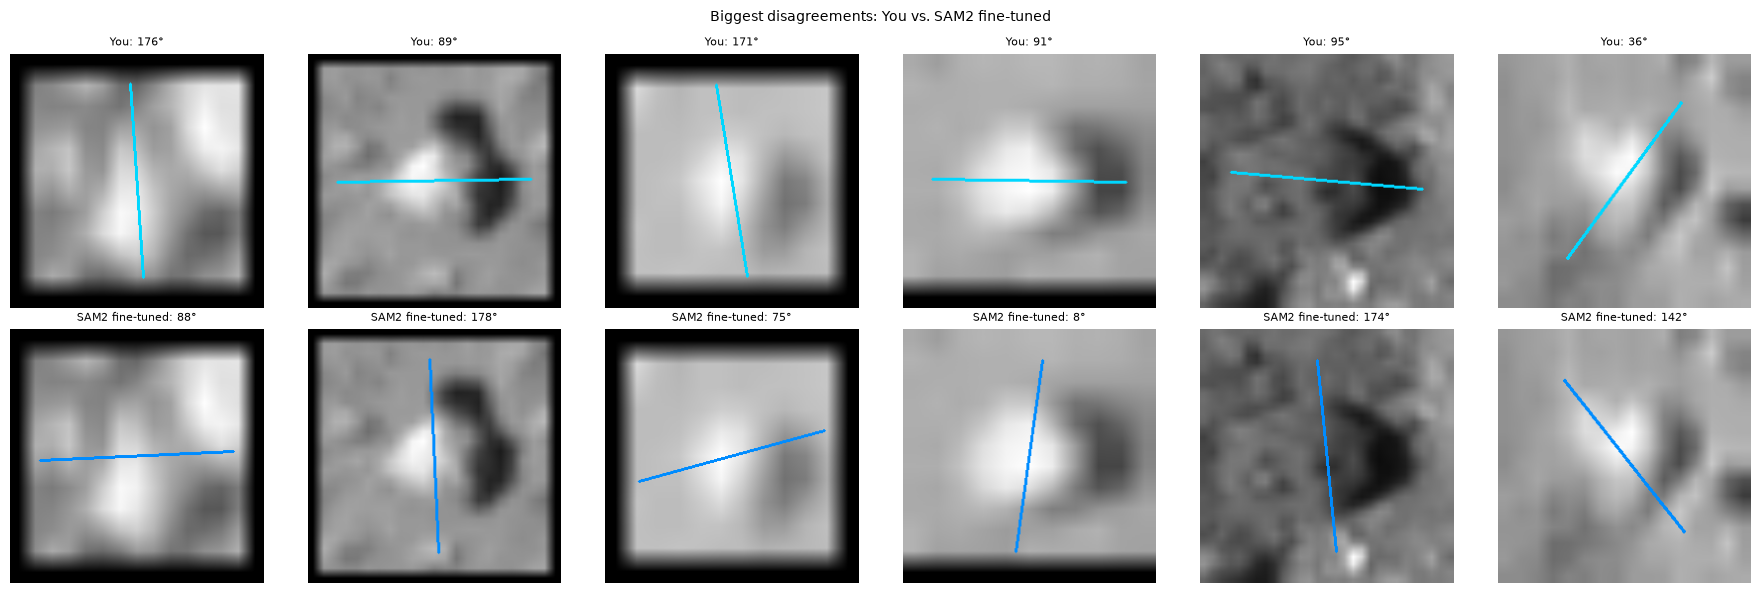

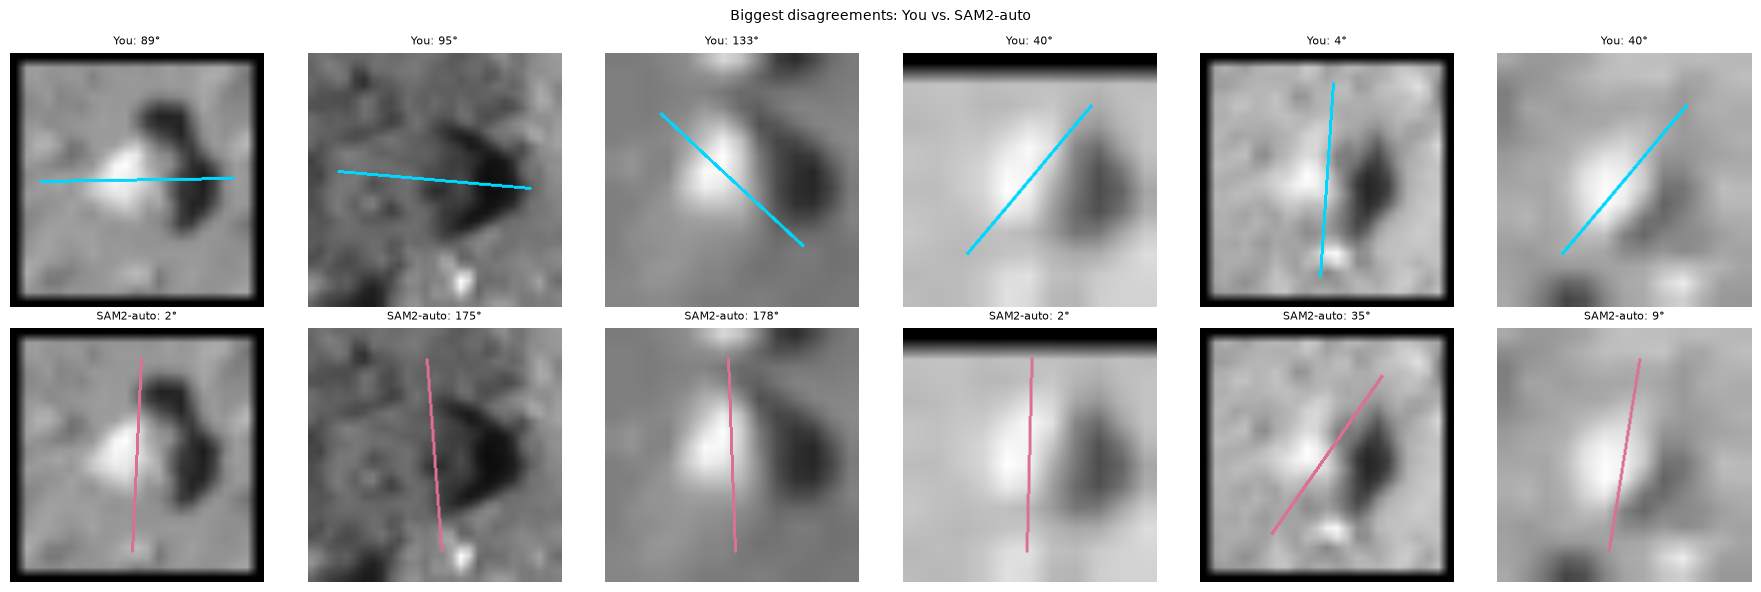

In [9]:
# ── Biggest disagreements ──────────────────────────────────────────────────────
# Show the boulders where you and the models disagree most

for mkey, acol in angle_cols.items():
    valid = df_merged[["boulder_id", "user_angle", acol]].dropna()
    if valid.empty:
        continue
    valid = valid.copy()
    valid["err"] = np.minimum(
        np.abs(valid["user_angle"] - valid[acol]),
        180 - np.abs(valid["user_angle"] - valid[acol])
    )
    top = valid.nlargest(6, "err")

    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for col_i, (_, br) in enumerate(top.iterrows()):
        bid = str(br["boulder_id"])
        crop_img = cv2.imread(str(CROPS_DIR / "crops" / f"{bid}.png"), cv2.IMREAD_GRAYSCALE)
        if crop_img is None:
            continue
        H, W = crop_img.shape
        cx, cy = W // 2, H // 2

        for row_i, (angle, color, label) in enumerate([
            (br["user_angle"], "gold",              "You"),
            (br[acol],         MODEL_COLORS[mkey],  MODEL_LABELS[mkey]),
        ]):
            img_rgb = cv2.cvtColor(crop_img, cv2.COLOR_GRAY2RGB)
            ax = axes[row_i, col_i]
            ax.imshow(img_rgb)
            # Draw orientation line
            L   = min(H, W) * 0.38
            rad = np.radians(angle)
            dx, dy = np.sin(rad) * L, -np.cos(rad) * L
            cv_color = (255, 215, 0) if color == "gold" else tuple(int(c*255) for c in plt.cm.colors.to_rgb(color))
            cv2.line(img_rgb, (int(cx-dx), int(cy-dy)), (int(cx+dx), int(cy+dy)),
                     cv_color[::-1], 2)
            ax.imshow(img_rgb)
            ax.set_title(f"{label}: {angle:.0f}°", fontsize=8)
            if row_i == 0:
                ax.set_xlabel(f"err={br['err']:.0f}°", fontsize=7)
            ax.axis("off")

    plt.suptitle(f"Biggest disagreements: You vs. {MODEL_LABELS[mkey]}", fontsize=10)
    plt.tight_layout()
    plt.savefig(CROPS_DIR / f"disagreements_{mkey}.png", dpi=150, bbox_inches="tight")
    plt.show()